# 3) Radial Metallicity Relations in Simulations

We use the FITS file nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits in the data folder. It contains the gas-phase metallicity $A(O)$ and $(x,y,z)$ positions of gas particles within $R_{Gal}=\sqrt{x^2+y^2} < 25\,kpc$. We start by importing python packages and our data.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d

In [2]:
data = Table.read('../data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')

In [5]:
x = data['x']
y = data['y']
z = data['z']
A_O = data['A_O']

Now, we compute the galactocentric cylindrical radius $R_{gal}=\sqrt{x^2+y^2}$.

In [6]:
# Compute R_Gal
R_gal = np.sqrt(x**2 + y**2)

1. We want to plot a two-panel figure containing a logarithmic density plot of $R_{gal}$ versus A(O) with a linear fit and legend and the residuals of the fit versus $R_{gal}$. We already have $R_gal$. Next, we perform the linear fit.

In [ ]:
# Linear fit
def lin_func(x, m, b):
    return m * x + b

popt, pcov = curve_fit(lin_func, R_gal, A_O)

# Parameters of the fit
m_fit, b_fit = popt

# Round to two decimals for the plot
m_fit_round, b_fit_round = np.round(m_fit, 2), np.round(b_fit, 2)

In [20]:
x_fit = np.linspace(R_gal.min(), R_gal.max(), 200)
y_fit = lin_func(x_fit, m_fit, b_fit)

In [38]:
A_O_fit = lin_func(R_gal, m_fit, b_fit)

residuals = A_O - A_O_fit

/tmp/ipykernel_123248/342382456.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


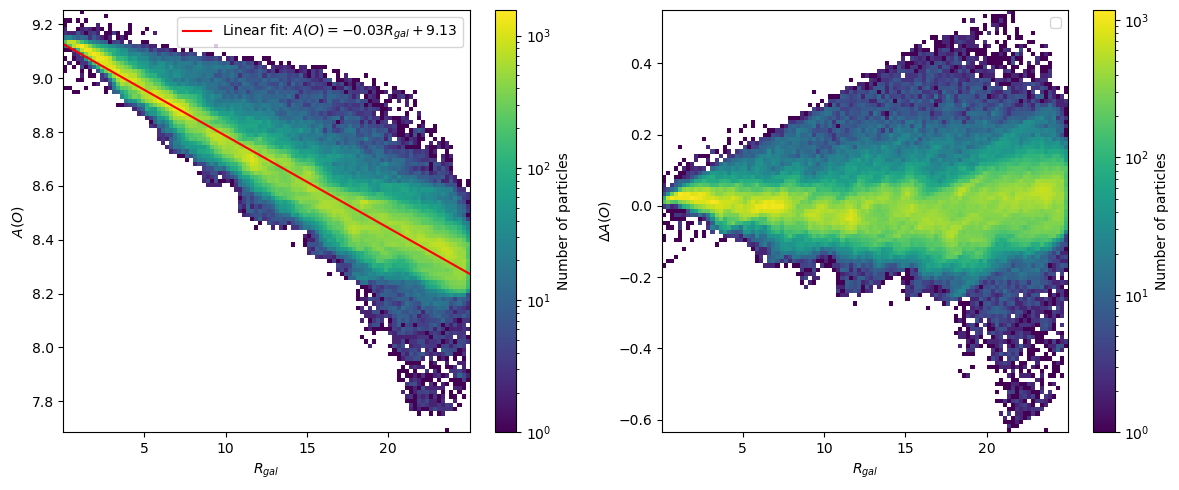

In [86]:
# Create two-panel figure with the two given plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

h1 = ax[0].hist2d(R_gal, A_O, bins=100, norm=LogNorm(), cmap='viridis')
ax[0].plot(x_fit, y_fit, label=rf'Linear fit: $A(O)={m_fit_round} R_{{gal}} + {b_fit_round}$', color='red')
ax[0].set_xlabel(r'$R_{gal}$')
ax[0].set_ylabel(r'$A(O)$')
ax[0].legend()
plt.colorbar(h1[3], ax=ax[0], label='Number of particles')

h2 = ax[1].hist2d(R_gal, residuals, bins=100, norm=LogNorm(), cmap='viridis')
ax[1].set_xlabel(r'$R_{gal}$')
ax[1].set_ylabel(r'$\Delta A(O)$')
ax[1].legend()
plt.colorbar(h2[3], ax=ax[1], label='Number of particles')

plt.tight_layout()
plt.savefig('../figures/M67_diagrams.png')  # Save figure in the folder figures
plt.show()

In [57]:
# Compute the uncertainties of the linear fit
m_err, b_err = np.sqrt(np.diag(pcov))

# Report the slope, intercept and its uncertainties
print("The slope is: ", m_fit)
print("The intercept is: ", b_fit)
print("The uncertainty of the slope is: ", m_err)
print("The uncertainty of the intercept is: ", b_err)

The slope is:  -0.03419647244403912
The intercept is:  9.127839305503603
The uncertainty of the slope is:  1.4802363881818711e-05
The uncertainty of the intercept is:  0.0002322764167036402


We have plotted $A(O)$ versus $R_{gal}$ on the left and fit it with the linear function $A(O) = -0.03 R_{gal} + 9.13$ where we have used the python fitting function curve_fit from scipy. Hence, the slope of the linear function is -0.03 and the intercept is 9.13. We computed the uncertainties of the slope and the intercept by taking the square root of the diagonal of the covariance matrix. In total, we get for the slope m and the intercept b

\begin{align}
    m = -0.034196 \pm 0.000015 \\
    b = 9.12784 \pm 0.00023
\end{align}

For the linear fit, we have used the default hyperparameters of the curve_fit scipy function. These are initial guesses of 1 for all parameters, an unweighted fit, and the use of the Levenberg-Marquardt algorithm.

The density of the number of particles is represented by a logairthmic colorbar. We have computed the residuals of $A(O)$ by $\Delta A(O) = A(O) - A_{fit}(O)$ where $A_{fit}(O)$ is the expected value of $A(O)$ according to the linear fit. We have plotted the residuals versus $R_{gal}$ on the right. 

3. We discuss where the linear model fits well and where it does not. Visibly, we can see that the residuals are small for small $R_{gal}$ and get larger with larger $R_{gal}$. We discuss this quantitively by taking the root mean square (RMS). We first compute the RMS for the whole sample. Then, we compute it for different bins to compare how good the fit is in different regions.

In [66]:
# Overall RMS
rms = np.sqrt(np.mean(residuals**2))
print(f"Overall RMS: {rms:.5f}")

Overall RMS: 0.07265


In [ ]:

# Total predicted change in unitless dimensions
total_predicted_change = abs(m_fit) * (R_gal.max() - R_gal.min())
print(f"Total predicted change in A(O): {total_predicted_change:.4f}")

Total predicted change in A(O): 0.8537


We find an overall RMS of 0.07265. Considering the slope of the linear fit of $\sim -0.3$ over , this is a reasonable value. Now, we want to test the RMS for different regions depending on the radius $R_{gal}$. Therefore, we create 10 bins. For each we compute the RMS and plot it against the center of the corresponding bin.

In [67]:
# Define radial bins
n_bins = 10
bin_edges = np.linspace(R_gal.min(), R_gal.max(), n_bins+1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

rms_bins = []

for i in range(n_bins):
    mask = (R_gal >= bin_edges[i]) & (R_gal < bin_edges[i+1])
    bin_rms = np.sqrt(np.mean(residuals[mask]**2))
    rms_bins.append(bin_rms)

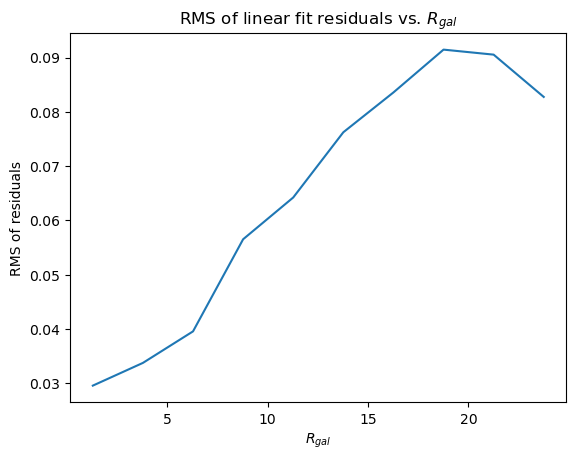

In [68]:
plt.figure()
plt.plot(bin_centers, rms_bins)
plt.xlabel(r'$R_{gal}$')
plt.ylabel('RMS of residuals')
plt.title(r'RMS of linear fit residuals vs. $R_{gal}$')
plt.savefig('../figures/rms_radius.png')
plt.show()

We can see that the RMS is small for small $R_{gal}$ ($\sim 0.03$). The RMS increases until a value of over 0.09 at $R_{gal} \approx 19$. Then, it decreases slightly again. Hence, the linear model fits well only for small values of $R_{gal}$ but not for larger ones.

4. We want to plot a three-panel figure for the x vs. y plane using the same bins and colormaps. The first figure should show a 2D histogram of the median simulated $A(O)$. The second one should show a 2D histogram of the median fitted $A(O)$ and the third one should show a 2D histogram of the median residuals $\Delta A(O)$. We first prepare the bins in the x-y plane on a 50x50-grid. Then, we use the scipy package binned_statistic_2d to compute the mean in the three cases.

In [95]:
# Prepare bins in x-y plane
n = 60
x_edges = np.linspace(x.min(), x.max(), n+1)
y_edges = np.linspace(y.min(), y.max(), n+1)

# Median simulated A(O)
median_AO, _, _, _ = binned_statistic_2d(x, y, A_O, statistic='median', bins=[x_edges, y_edges])

# Median fitted A(O)
A_O_fit = lin_func(R_gal, m_fit, b_fit)
median_fitted_AO, _, _, _ = binned_statistic_2d(x, y, A_O_fit, statistic='median', bins=[x_edges, y_edges])

# Median Residuals 
median_residuals, _, _, _ = binned_statistic_2d(x, y, residuals, statistic='median', bins=[x_edges, y_edges])

/tmp/ipykernel_123248/1474889561.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_123248/1474889561.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()
/tmp/ipykernel_123248/1474889561.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


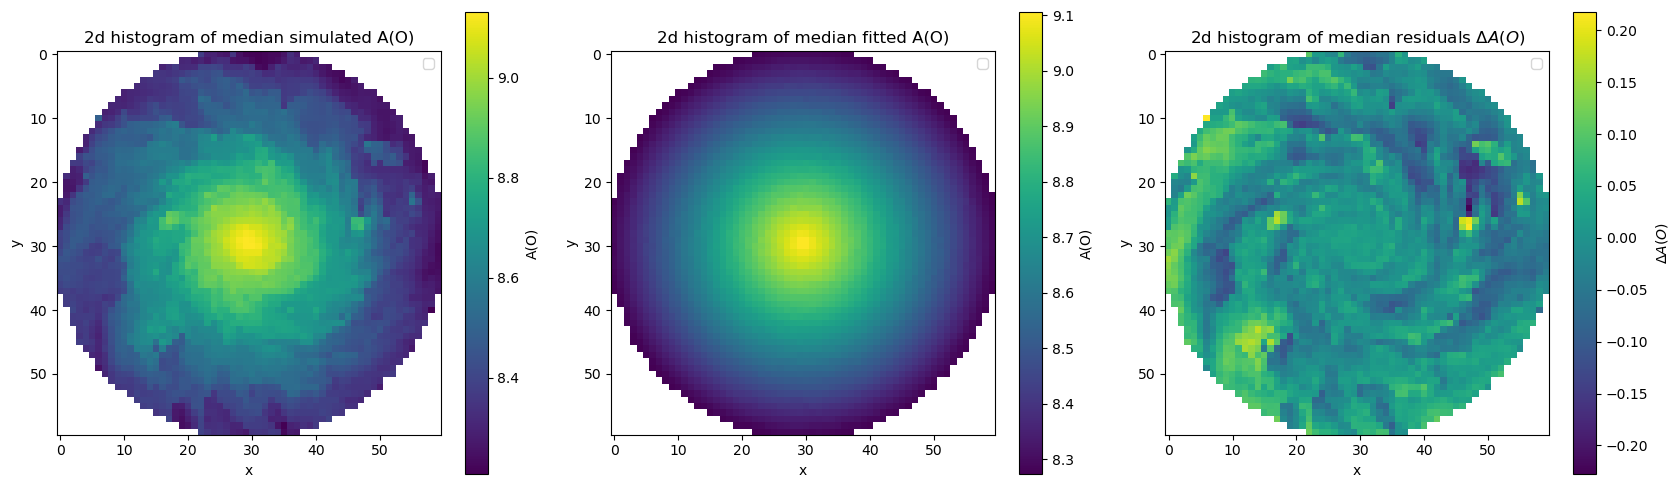

In [96]:
# Create two-panel figure with the two given plots
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

im0 = ax[0].imshow(median_AO.T)
plt.colorbar(im0, ax=ax[0], label='A(O)')

im1 = ax[1].imshow(median_fitted_AO.T)
plt.colorbar(im1, ax=ax[1], label='A(O)')

im2 = ax[2].imshow(median_residuals.T)
plt.colorbar(im2, ax=ax[2], label=r'$\Delta A(O)$')

ax[0].set_xlabel(r'x')
ax[0].set_ylabel(r'y')
ax[0].set_title('2d histogram of median simulated A(O)')
ax[0].legend()

ax[1].set_xlabel(r'x')
ax[1].set_ylabel(r'y')
ax[1].set_title('2d histogram of median fitted A(O)')
ax[1].legend()

ax[2].set_xlabel(r'x')
ax[2].set_ylabel(r'y')
ax[2].set_title(r'2d histogram of median residuals $\Delta A(O)$')
ax[2].legend()

plt.tight_layout()
plt.savefig('../figures/2d_histograms_AO_residuals.png')  # Save figure in the folder figures
plt.show()

5. We have used a 60x60-grid of bins. When using more bins, the computational cost would increase. Also, in every bin, there would only be a few gas particles left that would make the statistics less significant and the data noisy. With too many bins, some bins might even contain no particles, leading to NaN values. 
With less bins, the resolution would decrease and the figures would be less detailed. This means that certain structures, such as spiral arms or local metallicity clumps and inhomogeneities would be missed. 
The choice of a 50x50-grid is a trade-off between these two extremes, trying to consider local effects without losing statistical significance. When choosing a 80x80-grid, we can already see some white bins, which means that there is no data.

6. Now, we want to analyse the residuals in more detail. In the figure, we can clearly see spirals in the residual plot. This is because the linear model assumes radial symmetry and does not account for any spiral arms that exist in real galaxies, as can be seen in the left figure. Also, there are a few small local areas of high residuals. We can see in the left figure, that there is a higher local metallicity in these areas. This could be due to high star formation. These local inhomogeneities cannot be modeled by the linear fit. Hence, we get a high residual here.